In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('default')

## `Problem 1 to 5`:

Dataset link: https://tinyurl.com/2fe6vz4u

**Add a label to every axis and add a proper title for the charts. Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **`Problem-1:`** Draw a line plot of which, the x-axis is the "Year" and the y-axis is sum of "PM2.5" of two countries Iran and China.

In [3]:
# code here
df = pd.read_csv('https://tinyurl.com/2fe6vz4u')
df.head()

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018
3,3,4,India,Varanasi,2016,146,>75%,260,NaN,2018
4,4,5,India,Patna,2016,144,>75%,266,NaN,2018


In [4]:
temp_df = df[(df['Country'] == 'China') | (df['Country'] == 'Iran')].groupby(['Country','Year'])['PM2.5'].mean()
temp_df

Country  Year
China    2014    52.403846
         2015    70.833333
         2016    49.360000
Iran     2012    37.000000
         2013    66.000000
         2014    31.000000
         2016    36.325000
Name: PM2.5, dtype: float64

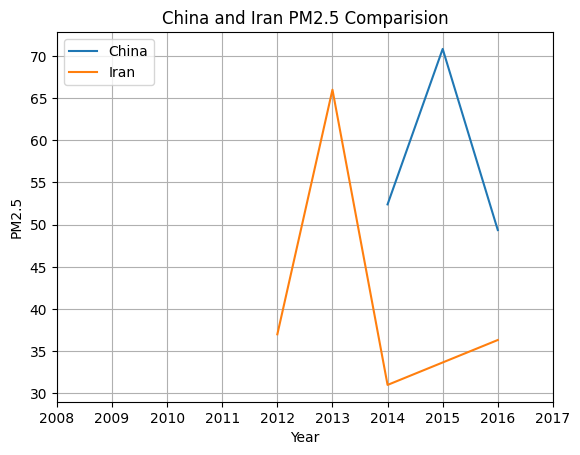

In [5]:
plt.title('China and Iran PM2.5 Comparision')
temp_df['China'].plot(label='China')
temp_df['Iran'].plot(label='Iran')
plt.xlabel('Year')
plt.ylabel('PM2.5')
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.legend(loc='upper left')
plt.xticks(df['Year'].value_counts().index)
plt.grid(True)
plt.show()


### **`Problem-2:`** Draw a histogram of the  column "PM10" of which the y-axis represents the probability (see the documentation how to draw the probability).

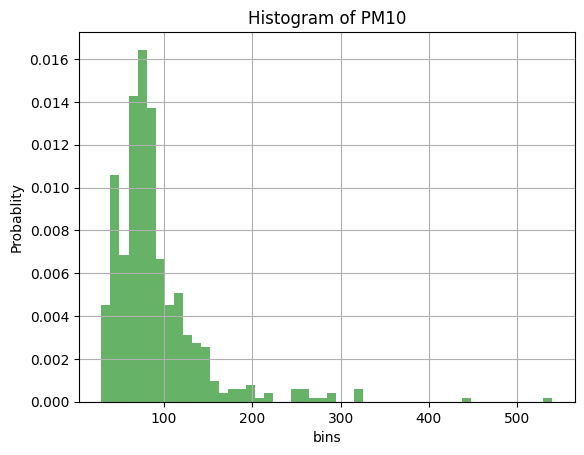

In [6]:
plt.hist(df['PM10'],density=True,bins = 50,facecolor='green',alpha=0.6)
plt.xlabel('bins')
plt.ylabel('Probablity')
plt.title('Histogram of PM10')
plt.grid(True)
plt.show()

### **`Problem-3:`** Draw a scatter plot where x-axis represents "PM2.5" and y-axis represents "PM10" for two countries Poland and Chile.

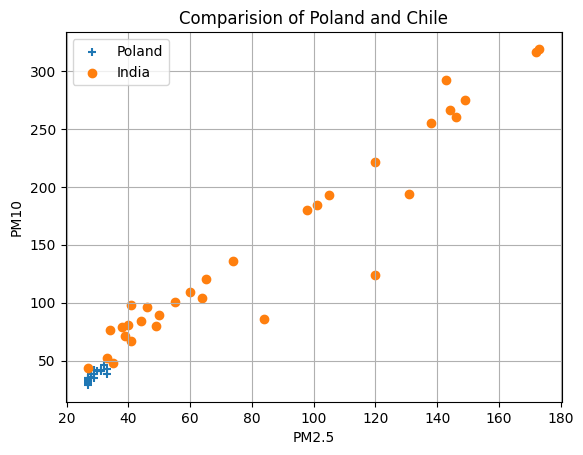

In [7]:
# code here
temp_df = df[(df['Country'] == 'Poland') | (df['Country'] == 'India')][['Country','Year','City/Town','PM2.5','PM10']]
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.title('Comparision of Poland and Chile')
plt.scatter(temp_df[temp_df['Country'] == 'Poland']['PM2.5'],temp_df[temp_df['Country'] == 'Poland']['PM10'],label='Poland',marker='+')
plt.scatter(temp_df[temp_df['Country'] == 'India']['PM2.5'],temp_df[temp_df['Country'] == 'India']['PM10'],label='India')
plt.legend()
plt.grid()
plt.show()

### **`Problem-4:`** Draw a pie chart of top 5 most frequent countries.

In [8]:
frequent_country = (df['Country'].value_counts().head(5))

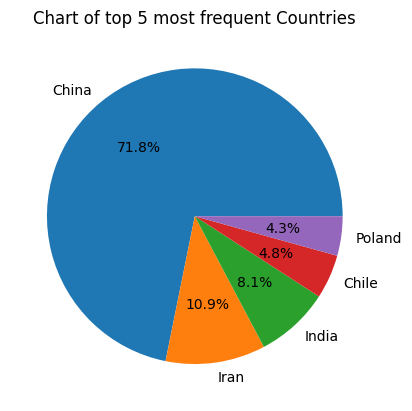

In [9]:
plt.pie(frequent_country,autopct='%0.1f%%',labels=frequent_country.index)
plt.title('Chart of top 5 most frequent Countries')
plt.show()


### **`Problem-5:`** Draw a bar chart which represents the counts of top 5 most frequent countries.



In [10]:
# code here
frequent_country = df['Country'].value_counts().head(5)
frequent_country

Country
China     283
Iran       43
India      32
Chile      19
Poland     17
Name: count, dtype: int64

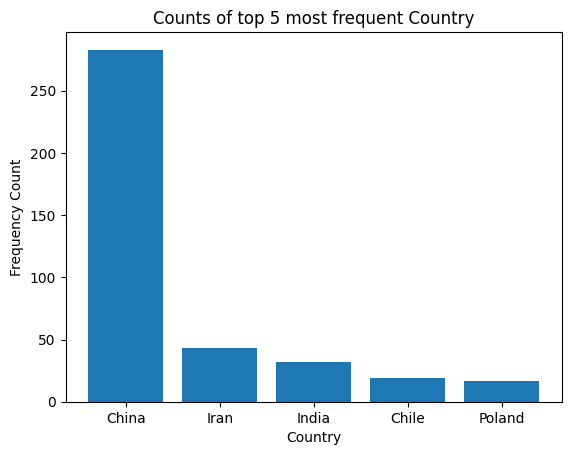

In [11]:
plt.bar(frequent_country.index,frequent_country)
plt.title('Counts of top 5 most frequent Country')
plt.xlabel('Country')
plt.ylabel('Frequency Count')
plt.show()

##`Problem 6-10`
Data Set - https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv

This is a Sales data of any company in a Year.


###`Problem-6`
Show a line plot of Total Profit for each month with below styling.
* Dotted Line
* Line Color Blue
* Show Legend at top left
* Circle Marker

In [12]:
# code here
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv')


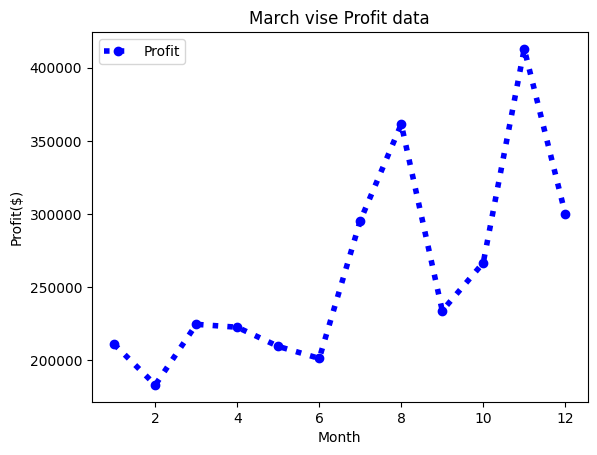

In [13]:
plt.plot(df['month_number'],df['total_profit'],color='blue',linestyle='dotted',linewidth=4,marker='o',label='Profit')
plt.xlabel('Month')
plt.title('March vise Profit data')
plt.ylabel('Profit($)')
plt.legend(loc='upper left')
plt.show()

###`Problem-7`
Show sales of each product in march month as pie chart.
* Show Percentage value
* Give Title "Sales in March"
* Explode ToothPaste with shadow

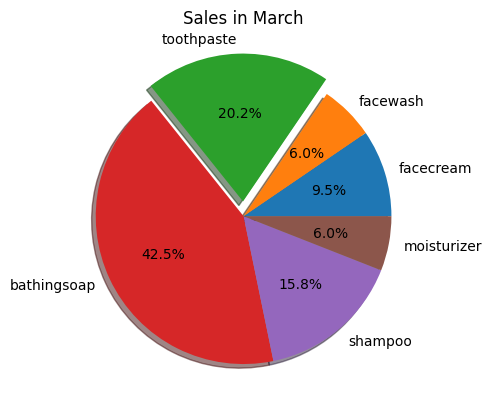

In [14]:
# code here
temp_df = df[df['month_number'] == 3][['facecream','facewash','toothpaste','bathingsoap','shampoo','moisturizer']].stack().reset_index().drop('level_0',axis=1).set_index('level_1')
plt.pie(temp_df[0],labels=temp_df.index,autopct='%0.1f%%',shadow=True,explode=[0,0,0.1,0,0,0])
plt.title('Sales in March')
plt.show()

###`Problem-8` Multiline Plot of all products sales.
* Give different styes for each products
* Add legend at top right

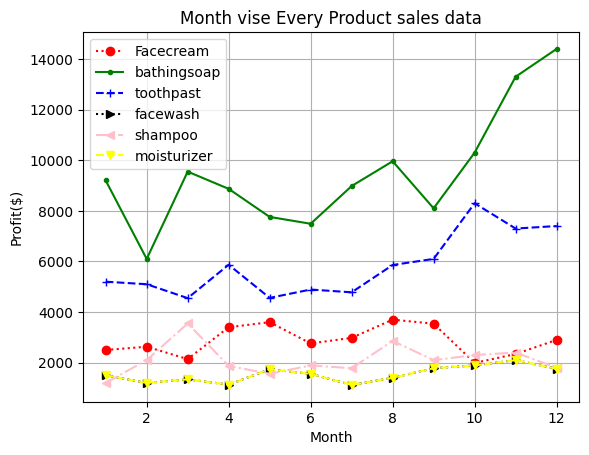

In [16]:
# code here
plt.plot(df['month_number'],df['facecream'],label='Facecream',color='red',marker='o',linestyle='dotted')
plt.plot(df['month_number'],df['bathingsoap'],label='bathingsoap',color='green',marker='.',linestyle='solid')
plt.plot(df['month_number'],df['toothpaste'],label='toothpast',color='blue',marker='+',linestyle='dashed')
plt.plot(df['month_number'],df['facewash'],label='facewash',color='black',marker='>',linestyle='dotted')
plt.plot(df['month_number'],df['shampoo'],label='shampoo',color='pink',marker='<',linestyle='dashdot')
plt.plot(df['month_number'],df['moisturizer'],label='moisturizer',color='yellow',marker='v',linestyle='--')
plt.legend()
plt.title('Month vise Every Product sales data')
plt.xlabel('Month')
plt.ylabel('Profit($)')
plt.grid()
plt.show()

###`Problem-9` Show Quarter wise Sales data for all products as multi Bar chart.


In [17]:
# code here
df['Quarter'] = [1,1,1,2,2,2,3,3,3,4,4,4]
temp_df = df[['facecream','facewash','toothpaste','bathingsoap','shampoo','moisturizer','Quarter']]
temp_df = temp_df.groupby('Quarter').sum()
temp_df

,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer
Quarter,,,,,,
1,7270,4040,14850,24850,6850,4040
2,9760,4425,15320,24120,5320,4425
3,10220,4300,16740,27040,6740,4300
4,7230,5750,23000,38000,6500,5750


In [ ]:
# plt.bar(np.arange(temp_df.shape[0]) -0.30,temp_df['facecream'],width=0.1,label='Facecream')
# plt.bar(np.arange(temp_df.shape[0]) -0.20,temp_df['facewash'],width=0.1,label='facewash')
# plt.bar(np.arange(temp_df.shape[0]) -0.10,temp_df['toothpaste'],width=0.1,label='toothpaste')
# plt.bar(np.arange(temp_df.shape[0]),temp_df['bathingsoap'],width=0.1,label='bathingsoap')
# plt.bar(np.arange(temp_df.shape[0])+0.1,temp_df['shampoo'],width=0.1,label='shampoo')
# plt.bar(np.arange(temp_df.shape[0])+0.2,temp_df['moisturizer'],width=0.1,label='moisturizer')
# plt.legend()
# plt.xlabel('Quarter')
# plt.ylabel('Profit($)')
# plt.show()
np.arange(temp_df.shape[0])

array([0, 1, 2])

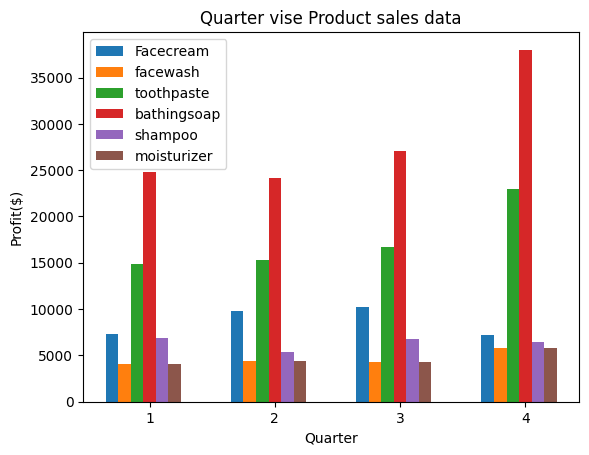

In [18]:
plt.bar(np.array([1, 2, 3,4]) -0.30,temp_df['facecream'],width=0.1,label='Facecream')
plt.bar(np.array([1, 2, 3,4]) -0.20,temp_df['facewash'],width=0.1,label='facewash')
plt.bar(np.array([1, 2, 3,4]) -0.10,temp_df['toothpaste'],width=0.1,label='toothpaste')
plt.bar(np.array([1, 2, 3,4]) ,temp_df['bathingsoap'],width=0.1,label='bathingsoap')
plt.bar(np.array([1, 2, 3,4]) +0.1,temp_df['shampoo'],width=0.1,label='shampoo')
plt.bar(np.array([1, 2, 3,4]) +0.2,temp_df['moisturizer'],width=0.1,label='moisturizer')
plt.legend()
plt.title('Quarter vise Product sales data')
plt.xlabel('Quarter')
plt.ylabel('Profit($)')
plt.xticks(np.array([1, 2, 3,4]))
plt.show()

###`Problem-10` Plot Stacked Bar chart quarter wise for each product.

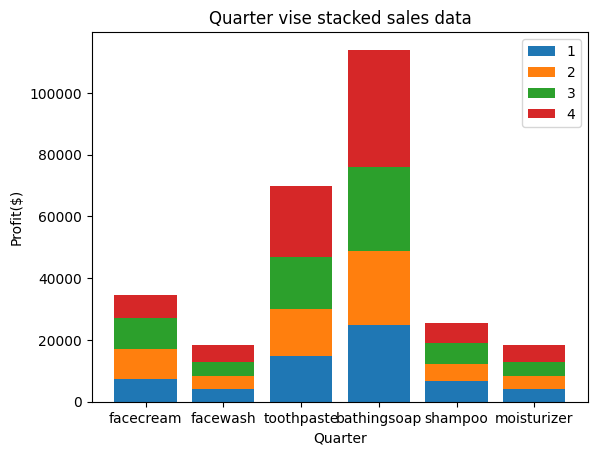

In [26]:
all_cols = []

# for col in temp_df.columns
plt.bar(temp_df.columns , temp_df.iloc[0],label = '1')
plt.bar(temp_df.columns , temp_df.iloc[1],bottom = temp_df.iloc[0],label = '2')
plt.bar(temp_df.columns , temp_df.iloc[2],bottom = temp_df.iloc[1] + temp_df.iloc[0],label = '3')
plt.bar(temp_df.columns , temp_df.iloc[3],bottom = temp_df.iloc[1] + temp_df.iloc[0] + temp_df.iloc[2],label = '4')
plt.title('Quarter vise stacked sales data')
plt.xlabel('Quarter')
plt.ylabel('Profit($)')
plt.legend()
plt.show()
